In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
# !rm -rf /content/dataset_folder

In [47]:
# !rm -rf /content/dataset_90_10

In [34]:
# !rm -rf /content/dataset_folder/__MACOSX

In [35]:
# # Run this inside a Colab Code Cell
!cp "/content/drive/MyDrive/Main Project/dataset.zip" /content/dataset.zip

In [36]:
!unzip -q /content/dataset.zip -d /content/dataset_folder

In [37]:
!ls /content/dataset_folder

dataset  __MACOSX


In [38]:
!rm -rf /content/dataset_folder/__MACOSX
!ls /content/dataset_folder/dataset

train  val


# Strong Lensing Image Classification using PyTorch

## Problem Statement
The goal of this project is to build a deep learning model that classifies gravitational lensing images into three categories:

- no: strong lensing images with no substructure
- sphere: strong lensing images with subhalo substructure
- vort: strong lensing images with vortex substructure

The dataset is provided in `.npy` format, where each file contains a normalized grayscale image. The evaluation requires not only classification performance, but also ROC curves and AUC scores.

This notebook presents a complete end-to-end pipeline including:
- data preparation
- optional 90:10 train-validation split
- model training
- validation
- ROC/AUC evaluation
- model saving

## Strategy Discussion

### Why PyTorch was selected
PyTorch was chosen as the primary framework because the dataset is stored in `.npy` format instead of standard image formats such as PNG or JPG. PyTorch makes it straightforward to build a custom `Dataset` class that directly loads NumPy arrays, applies controlled augmentation, and converts them into tensors for training. This approach provides full flexibility and is especially well suited for research-style image classification problems.

### Why a custom CNN architecture was used
A custom Convolutional Neural Network (CNN) was selected as the first modeling approach because the task is an image classification problem involving subtle spatial patterns. CNNs are highly effective for extracting hierarchical image features such as local edges, textures, and higher-level structural patterns. Since the input images are grayscale and relatively small in size, a custom CNN provides a clean and efficient baseline without adding unnecessary complexity. The model includes convolutional layers, batch normalization, ReLU activation, max pooling, and dropout to balance feature learning and regularization.

### Why CrossEntropyLoss was used
The task is a multi-class single-label classification problem with three mutually exclusive classes. CrossEntropyLoss is the standard loss function for this setup because it is designed to compare the model’s raw class logits against integer class labels efficiently and stably.

### Why these augmentation methods were used
The dataset images are already normalized, so aggressive preprocessing is not necessary. However, limited geometric augmentation such as horizontal flips and vertical flips can improve generalization by exposing the model to slightly varied spatial arrangements. The augmentation strategy was intentionally kept conservative to avoid distorting the scientific structure in the images too aggressively.

### Why ROC and AUC were emphasized
Although accuracy is useful, it does not fully capture how well the model separates the classes. ROC curves and AUC scores provide a stronger view of class separability across thresholds. Since the project guidelines explicitly require ROC and AUC, the evaluation is performed using a one-vs-rest multi-class ROC setup.

### Model development philosophy
The modeling strategy follows a baseline-first approach:
1. build a reliable custom CNN baseline
2. verify the end-to-end pipeline
3. inspect learning curves and confusion patterns
4. use ROC/AUC to judge separability
5. extend later to transfer learning or more advanced tuning if required

This is a practical and defensible workflow commonly used in applied machine learning projects.

## Step 1: Import Libraries
This section imports all required libraries for:
- file handling
- numerical operations
- visualization
- deep learning
- model evaluation

In [39]:
!pip install torch torchvision scikit-learn matplotlib seaborn tqdm -q

In [40]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve,
    auc,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.preprocessing import label_binarize

## Step 2: Set Random Seeds and Device
To make the experiment more reproducible, we fix random seeds.  
We also detect whether a GPU is available and use it if possible.

In [41]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Step 3: Define Dataset Paths
This notebook assumes the original dataset is stored as:

dataset/
    train/
        no/
        sphere/
        vort/
    val/
        no/
        sphere/
        vort/

Because a 90:10 split is required, the notebook will optionally create a new folder called `dataset_90_10`.

In [48]:
original_train_dir = "/content/dataset_folder/dataset/train"
original_val_dir = "/content/dataset_folder/dataset/val"

new_base_dir = "dataset_90_10"
new_train_dir = os.path.join(new_base_dir, "train")
new_val_dir = os.path.join(new_base_dir, "val")

classes = ["no", "sphere", "vort"]
class_to_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}

print("Class mapping:", class_to_idx)

Class mapping: {'no': 0, 'sphere': 1, 'vort': 2}


## Step 4: Create 90:10 Train-Validation Split
The provided dataset is already divided into train and validation folders, but the current split is approximately 80:20.
To create the required 90:10 split, all files from the existing train and validation folders are combined and then split again using a stratified split.

Stratification is important because it preserves class balance across train and validation sets.

In [49]:
import os
import shutil
from sklearn.model_selection import train_test_split
from tqdm import tqdm

def create_90_10_split(original_train_dir, original_val_dir, new_train_dir, new_val_dir, classes, seed=42):
    os.makedirs(new_train_dir, exist_ok=True)
    os.makedirs(new_val_dir, exist_ok=True)

    for split_dir in [new_train_dir, new_val_dir]:
        for cls in classes:
            os.makedirs(os.path.join(split_dir, cls), exist_ok=True)

    all_files = []
    all_labels = []

    for cls in classes:
        train_cls_dir = os.path.join(original_train_dir, cls)
        val_cls_dir = os.path.join(original_val_dir, cls)

        for fname in os.listdir(train_cls_dir):
            if fname.endswith(".npy"):
                all_files.append(os.path.join(train_cls_dir, fname))
                all_labels.append(cls)

        for fname in os.listdir(val_cls_dir):
            if fname.endswith(".npy"):
                all_files.append(os.path.join(val_cls_dir, fname))
                all_labels.append(cls)

    print("Total source files found:", len(all_files))

    train_files, val_files, train_labels, val_labels = train_test_split(
        all_files,
        all_labels,
        test_size=0.10,
        stratify=all_labels,
        random_state=seed
    )

    print("Expected train files:", len(train_files))
    print("Expected val files:", len(val_files))

    # Copy train files with unique names
    for idx, (file_path, label) in enumerate(tqdm(zip(train_files, train_labels), total=len(train_files), desc="Copying train files")):
        parent_split = os.path.basename(os.path.dirname(os.path.dirname(file_path)))   # train or val
        original_name = os.path.basename(file_path)
        new_name = f"{parent_split}_{idx}_{original_name}"
        dest_path = os.path.join(new_train_dir, label, new_name)
        shutil.copy2(file_path, dest_path)

    # Copy val files with unique names
    for idx, (file_path, label) in enumerate(tqdm(zip(val_files, val_labels), total=len(val_files), desc="Copying val files")):
        parent_split = os.path.basename(os.path.dirname(os.path.dirname(file_path)))   # train or val
        original_name = os.path.basename(file_path)
        new_name = f"{parent_split}_{idx}_{original_name}"
        dest_path = os.path.join(new_val_dir, label, new_name)
        shutil.copy2(file_path, dest_path)

    print("New 90:10 split created successfully.")

In [50]:
create_90_10_split(
    original_train_dir=original_train_dir,
    original_val_dir=original_val_dir,
    new_train_dir=new_train_dir,
    new_val_dir=new_val_dir,
    classes=classes,
    seed=SEED
)

Total source files found: 37500
Expected train files: 33750
Expected val files: 3750


Copying val files: 100%|██████████| 3750/3750 [00:07<00:00, 513.30it/s]

New 90:10 split created successfully.


## Step 5: Point the Training Pipeline to the New 90:10 Dataset
After creating the processed split, the remaining pipeline will use `dataset_90_10/train` and `dataset_90_10/val`.

In [51]:
train_dir = new_train_dir
val_dir = new_val_dir

print("Train directory:", train_dir)
print("Validation directory:", val_dir)

Train directory: dataset_90_10/train
Validation directory: dataset_90_10/val


## Step 6: Verify Class Distribution
Before training the model, it is good practice to verify that the new split is valid and that each class contains a reasonable number of samples.

In [52]:
def count_files(base_dir, classes):
    counts = {}
    for cls in classes:
        cls_dir = os.path.join(base_dir, cls)
        counts[cls] = len([f for f in os.listdir(cls_dir) if f.endswith(".npy")])
    return counts

train_counts = count_files(train_dir, classes)
val_counts = count_files(val_dir, classes)

print("Train distribution:", train_counts)
print("Validation distribution:", val_counts)
print("Total train files:", sum(train_counts.values()))
print("Total val files:", sum(val_counts.values()))

Train distribution: {'no': 11250, 'sphere': 11250, 'vort': 11250}
Validation distribution: {'no': 1250, 'sphere': 1250, 'vort': 1250}
Total train files: 33750
Total val files: 3750


## Step 7: Build a Custom Dataset for `.npy` Files
The dataset is stored in NumPy format, so a custom PyTorch `Dataset` is used to:
- load each `.npy` file
- apply optional augmentation
- convert images and labels into tensors

In [53]:
class LensDataset(Dataset):
    def __init__(self, root_dir, class_to_idx, augment=False):
        self.samples = []
        self.class_to_idx = class_to_idx
        self.augment = augment

        for class_name, label in class_to_idx.items():
            class_folder = os.path.join(root_dir, class_name)
            for file_name in os.listdir(class_folder):
                if file_name.endswith(".npy"):
                    file_path = os.path.join(class_folder, file_name)
                    self.samples.append((file_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, label = self.samples[idx]
        image = np.load(file_path).astype(np.float32)   # expected shape: (1, 150, 150)

        if self.augment:
            if np.random.rand() > 0.5:
                image = np.flip(image, axis=2).copy()
            if np.random.rand() > 0.5:
                image = np.flip(image, axis=1).copy()

        image = torch.tensor(image, dtype=torch.float32)
        label = torch.tensor(label, dtype=torch.long)

        return image, label

## Step 8: Create Dataset and DataLoader Objects
Training data uses augmentation and shuffling.  
Validation data does not use augmentation and is loaded without shuffling.

In [54]:
train_dataset = LensDataset(train_dir, class_to_idx, augment=True)
val_dataset = LensDataset(val_dir, class_to_idx, augment=False)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Train samples: 33750
Validation samples: 3750


## Step 9: Data Sanity Check
Before training, confirm that:
- a sample image loads correctly
- tensor shape is correct
- class labels map properly

In [55]:
sample_image, sample_label = train_dataset[0]
print("Sample image shape:", sample_image.shape)
print("Sample image dtype:", sample_image.dtype)
print("Sample label:", sample_label.item(), "->", classes[sample_label.item()])
print("Min pixel value:", sample_image.min().item())
print("Max pixel value:", sample_image.max().item())

Sample image shape: torch.Size([1, 150, 150])
Sample image dtype: torch.float32
Sample label: 0 -> no
Min pixel value: 0.0
Max pixel value: 1.0


## Step 10: Visualize Sample Images
This helps verify that the images and labels are aligned correctly and that the data pipeline is working as expected.

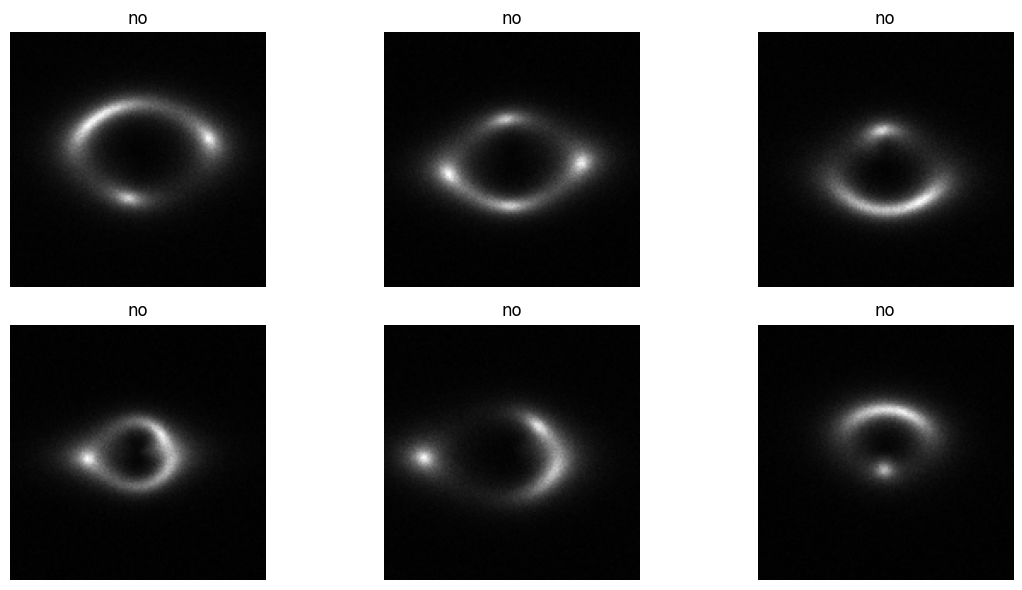

In [56]:
def show_samples(dataset, classes, n=6):
    plt.figure(figsize=(12, 6))
    for i in range(n):
        image, label = dataset[i]
        plt.subplot(2, 3, i + 1)
        plt.imshow(image.squeeze(0), cmap="gray")
        plt.title(classes[label.item()])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(train_dataset, classes)

## Step 11: Define the CNN Architecture
A custom CNN is used as the baseline model.  
The architecture includes:
- convolution layers for feature extraction
- batch normalization for training stability
- ReLU activations for non-linearity
- max pooling for spatial downsampling
- dropout for regularization

In [57]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 150 -> 75

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 75 -> 37

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 37 -> 18

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 18 -> 9
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 9 * 9, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [58]:
model = SimpleCNN(num_classes=3).to(device)
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

## Step 12: Define Loss Function, Optimizer, and Scheduler
- CrossEntropyLoss is used because this is a multi-class classification problem.
- Adam is used as the optimizer because it is a strong default choice for CNN training.
- A learning-rate scheduler is included to reduce the learning rate if validation loss stops improving.

In [60]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=3,
    factor=0.5
)

## Step 13: Define Training Function
This function performs one full training epoch.

In [61]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

## Step 14: Define Validation Function
This function runs the model in evaluation mode and stores:
- labels
- predicted probabilities
- predicted classes

These outputs are later used for:
- confusion matrix
- classification report
- ROC curve
- AUC score

In [62]:
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_probs = []
    all_preds = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation", leave=False):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * images.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_probs), np.array(all_preds)

## Step 15: Train the Model
This section trains the model for multiple epochs and stores training history for later visualization.

In [63]:
num_epochs = 15

train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_loss = float("inf")
best_model_path = "best_lens_classifier_cnn.pth"

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, y_true, y_probs, y_pred = validate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    scheduler.step(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        print(f"Best model saved to {best_model_path}")


Epoch 1/15


Train Loss: 1.1885 | Train Acc: 0.3309
Val   Loss: 1.0986 | Val   Acc: 0.3333
Best model saved to best_lens_classifier_cnn.pth

Epoch 2/15


Train Loss: 1.0987 | Train Acc: 0.3312
Val   Loss: 1.0986 | Val   Acc: 0.3333
Best model saved to best_lens_classifier_cnn.pth

Epoch 3/15


Train Loss: 1.0987 | Train Acc: 0.3297
Val   Loss: 1.0986 | Val   Acc: 0.3333

Epoch 4/15


Train Loss: 1.0987 | Train Acc: 0.3333
Val   Loss: 1.0986 | Val   Acc: 0.3333
Best model saved to best_lens_classifier_cnn.pth

Epoch 5/15


...

Train Loss: 1.0986 | Train Acc: 0.3299
Val   Loss: 1.0986 | Val   Acc: 0.3333

Epoch 12/15


Train Loss: 1.0986 | Train Acc: 0.3282
Val   Loss: 1.0986 | Val   Acc: 0.3333

Epoch 13/15


Train Loss: 1.0986 | Train Acc: 0.3321
Val   Loss: 1.0986 | Val   Acc: 0.3333

Epoch 14/15


Train Loss: 1.0986 | Train Acc: 0.3271
Val   Loss: 1.0986 | Val   Acc: 0.3333

Epoch 15/15


Train Loss: 1.0986 | Train Acc: 0.3293
Val   Loss: 1.0986 | Val   Acc: 0.3333


## Step 16: Plot Learning Curves
Learning curves help diagnose:
- convergence
- overfitting
- underfitting

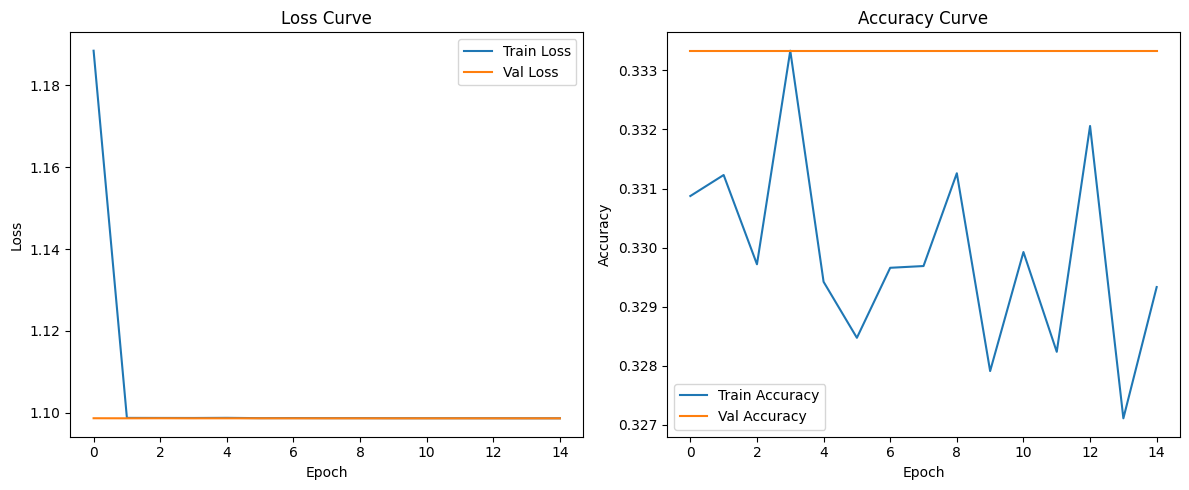

In [64]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Val Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## Step 17: Load the Best Model Before Final Evaluation
This ensures that all final evaluation metrics are computed using the best validation-loss checkpoint, not just the last epoch.

In [65]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
model.eval()

val_loss, val_acc, y_true, y_probs, y_pred = validate(model, val_loader, criterion, device)

print("Best Validation Loss:", round(val_loss, 4))
print("Best Validation Accuracy:", round(val_acc, 4))

Best Validation Loss: 1.0986
Best Validation Accuracy: 0.3333


## Step 18: Confusion Matrix
The confusion matrix helps reveal which classes are correctly identified and which classes are being confused.

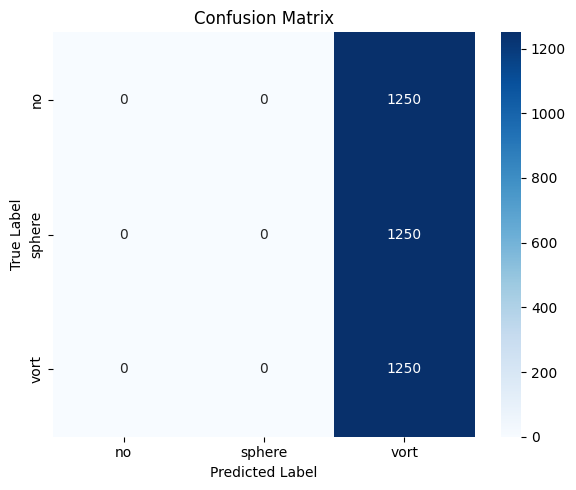

In [66]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## Step 19: Classification Report
This section reports precision, recall, and F1-score for each class.

In [67]:
print(classification_report(y_true, y_pred, target_names=classes))

              precision    recall  f1-score   support

          no       0.00      0.00      0.00      1250
      sphere       0.00      0.00      0.00      1250
        vort       0.33      1.00      0.50      1250

    accuracy                           0.33      3750
   macro avg       0.11      0.33      0.17      3750
weighted avg       0.11      0.33      0.17      3750



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Step 20: ROC Curve and AUC Score
For multi-class ROC analysis, a one-vs-rest strategy is used.  
Each class is treated as the positive class against the remaining classes.

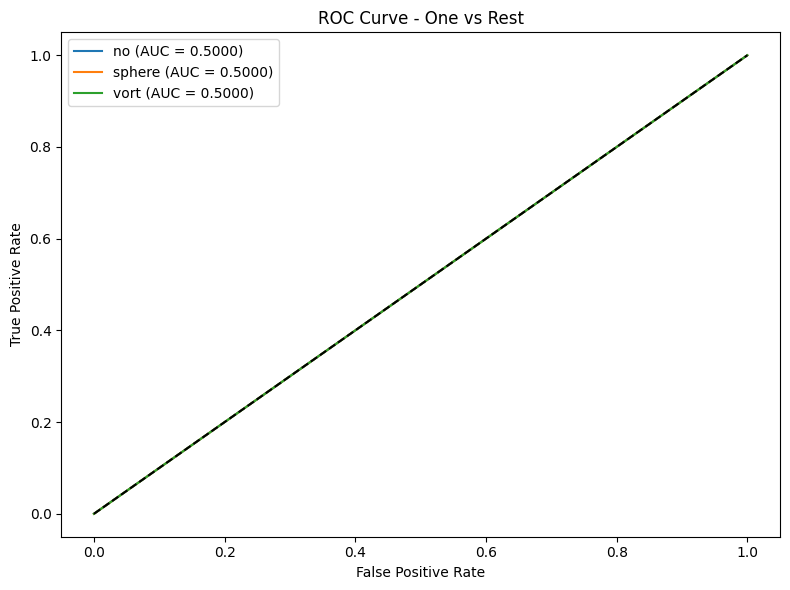

Macro AUC: 0.5
Weighted AUC: 0.5


In [68]:
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])

fpr = {}
tpr = {}
roc_auc = {}

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i, class_name in enumerate(classes):
    plt.plot(fpr[i], tpr[i], label=f"{class_name} (AUC = {roc_auc[i]:.4f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - One vs Rest")
plt.legend()
plt.tight_layout()
plt.show()

macro_auc = roc_auc_score(y_true_bin, y_probs, average="macro", multi_class="ovr")
weighted_auc = roc_auc_score(y_true_bin, y_probs, average="weighted", multi_class="ovr")

print("Macro AUC:", round(macro_auc, 4))
print("Weighted AUC:", round(weighted_auc, 4))

## Step 21: Save Final Model
The final trained model weights are saved for reuse and reproducibility.

In [69]:
final_model_path = "lens_classifier_final.pth"
torch.save(model.state_dict(), final_model_path)
print(f"Final model saved to {final_model_path}")

Final model saved to lens_classifier_final.pth


## Final Conclusion

This notebook built an end-to-end image classification pipeline for strong lensing images stored in `.npy` format. A custom PyTorch CNN was used as the baseline model because it is well suited for grayscale scientific image classification and allows direct handling of NumPy-based image files.

The workflow included:
- rebuilding the dataset into a 90:10 train-validation split
- constructing a custom dataset class
- training a CNN with controlled augmentation
- evaluating performance using confusion matrix, classification report, ROC curve, and AUC score
- saving the best model for future use

### Future Improvements
Possible next steps include:
- experimenting with transfer learning models such as ResNet18
- tuning learning rate and batch size
- introducing class-weighted loss if imbalance becomes significant
- using early stopping
- testing additional augmentation methods such as controlled rotations